# Indroduction

## Problem Statement

The sensory quality of wine is traditionally evaluated by human experts through wine tasting, which is a subjective, expensive, and time-consuming process. While chemical properties like acidity, alcohol content, and sulfur levels drastically impact flavor profiles, predicting how these chemical combinations collectively dictate human preference remains a complex challenge. To eliminate human bias and streamline production, wineries need an automated, data-driven method to objectively evaluate and predict wine quality based entirely on measurable physicochemical properties.

---

## Project Objective

The objective of this project is to develop an end-to-end Data Analysis and Multiple Linear Regression model capable of predicting a wine's quality score based on its chemical composition. By leveraging features such as residual sugar, alcohol percentage, and acidity levels, the model aims to establish a quantifiable relationship between scientific metrics and sensory scores, providing a scalable baseline for automated quality control.

---

## Data Scope & Preprocessing Statement

The dataset consists of various continuous physicochemical features (e.g., Volatile Acidity, Citric Acid, Total Sulfur Dioxide, Alcohol) and a discrete target variable (Quality Score). Because the raw telemetry contains mixed string formatting and physical units (such as 'g/L', 'mg/L SO2', and '% vol'), a targeted data cleaning pipeline using Regular Expressions (Regex) was implemented to extract pure numeric vectors. To optimize the Multiple Linear Regression model and account for widely differing metric scales (e.g., Density vs. Sulfur Dioxide levels), features were standardized using Z-score scaling ($StandardScaler$) prior to model training.

### Phase 0: Preparation

In [1]:
# Imports all library.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**What this cell does:** loads the core Python libraries used throughout the project.
- `numpy` / `pandas` — numeric arrays and the DataFrame used to hold the wine dataset.
- `matplotlib.pyplot` / `seaborn` — the plotting libraries used later in the EDA (Exploratory Data Analysis) phase.

No data has been touched yet — this is purely setup.


In [2]:
data = pd.read_csv('red_wine_quality.csv')

**What this cell does:** reads `red_wine_quality.csv` from the current working directory into a DataFrame called `data`.

**Note:** this assumes the notebook is run from the same folder as the CSV. If the notebook is moved (e.g. into a different project structure), this line will raise `FileNotFoundError` unless the path is updated.


### Phase 1: Data Cleaning & Preprocessing

In [3]:
# Rename all columns
data.columns = data.columns.str.lower().str.strip().str.replace(' ','_')

**What this cell does:** normalizes the column names — lowercases them, strips whitespace, and replaces spaces with underscores (e.g. `"Fixed Acidity"` → `fixed_acidity`).

This is why the Flask app's `FEATURE_LIMITS` dictionary keys (`fixed_acidity`, `volatile_acidity`, etc.) use the underscore form — they must match these exact column names for the app to correctly line up user input with the columns the model expects.


In [4]:
# Display all columns
data.columns

Index(['unnamed:_0', 'fixed_acidity', 'volatile_acidity', 'citric_acid',
       'residual_sugar', 'chlorides', 'free_sulfur_dioxide',
       'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol',
       'quality'],
      dtype='str')

**What this cell does:** simply prints the cleaned column names so you can visually confirm the renaming worked as expected before moving on.


In [5]:
# Update all rows value 
# Remove all symbols and keep only numbers
data_clean = data
for i in data_clean:
    if data_clean[i].dtypes == 'str':
        data_clean[i] = data_clean[i].str.strip().str.replace(r'[^0-9.]','',regex=True)

**What this cell does:** intends to strip out any non-numeric characters (units like `g/L`, `mg/L`, `% vol`) from the raw values using a regex, keeping only digits and decimal points.

**Something worth double-checking:** the condition is `if data_clean[i].dtypes == 'str':`. In pandas, text columns normally report their dtype as `object`, not the Python type `'str'`. Depending on your pandas version, this comparison may **never evaluate to `True`**, meaning the regex cleaning step could silently be skipped for every column. It's worth printing `data_clean.dtypes` right before this cell (or using `data_clean[i].dtype == object` instead) to confirm the cleaning is actually being applied to the columns that need it.


In [6]:
# Data type convertion
for i in data_clean.columns:
    if i != 'quality' and i != 'unnamed:_0':
        data_clean[i] = data_clean[i].astype(float)

data_clean['quality'] = data_clean['quality'].astype(int)
    

**What this cell does:** converts every column except `quality` and `unnamed:_0` to `float`, and converts `quality` itself to `int` (since wine quality scores are whole numbers, e.g. 3–8).

This is the step that would fail loudly (raising a `ValueError`) if the previous regex-cleaning cell had left any non-numeric text in a column — so a clean run here is indirectly a good sanity check that Cell 7 worked as intended.


In [7]:
# Check for null values
data_clean.isnull().sum()

#data_clean['name'] = data_clean['name'].fillna(data_clean['name'].mean())
# Run if null value found

unnamed:_0              0
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**What this cell does:** counts missing (`NaN`) values per column. The commented-out line below it (`data_clean['name'] = ...fillna(...)`) is a leftover snippet — a reminder of *how* you'd impute a column's missing values with its mean, kept here for reference but not currently active, presumably because no nulls were found.


In [8]:
# Check data type
data_clean.dtypes

unnamed:_0                int64
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
ph                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

**What this cell does:** confirms the dtype of every column after the conversions above — a quick check that every physicochemical feature is now numeric (`float64`) and `quality` is `int64`, ready for modeling.


### Phase 2: Exploratory Data Analysis (EDA)

In [9]:
# we don`t need of 'unnamed:_0' column
data_clean = data_clean.drop(columns='unnamed:_0')

**What this cell does:** drops the `unnamed:_0` column. This column typically comes from a CSV that was previously saved with `df.to_csv(...)` without `index=False` — pandas then re-imports the old row index as a normal column. It carries no predictive information, so removing it here is correct.


In [10]:
len(data_clean.columns)

12

**What this cell does:** confirms how many columns remain after dropping `unnamed:_0` — a quick sanity check (should be 12: 11 physicochemical features + `quality`).


In [11]:
# Descriptive Statistics
data_clean.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.894922,46.487792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.020000,6.020000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.020000,22.020000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.020000,38.020000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.020000,62.020000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.020000,289.020000,1.003690,4.010000,2.000000,14.900000,8.000000


**What this cell does:** `describe()` prints count, mean, std, min/max and quartiles for every numeric column. This is where the `FEATURE_LIMITS` min/max bounds used later in `app.py` were most likely derived from — they should be cross-checked against these actual min/max values to make sure the web form's allowed ranges genuinely reflect the training data's range (predicting far outside the range the model was trained on is unreliable, since linear regression doesn't "know" about values it never saw).


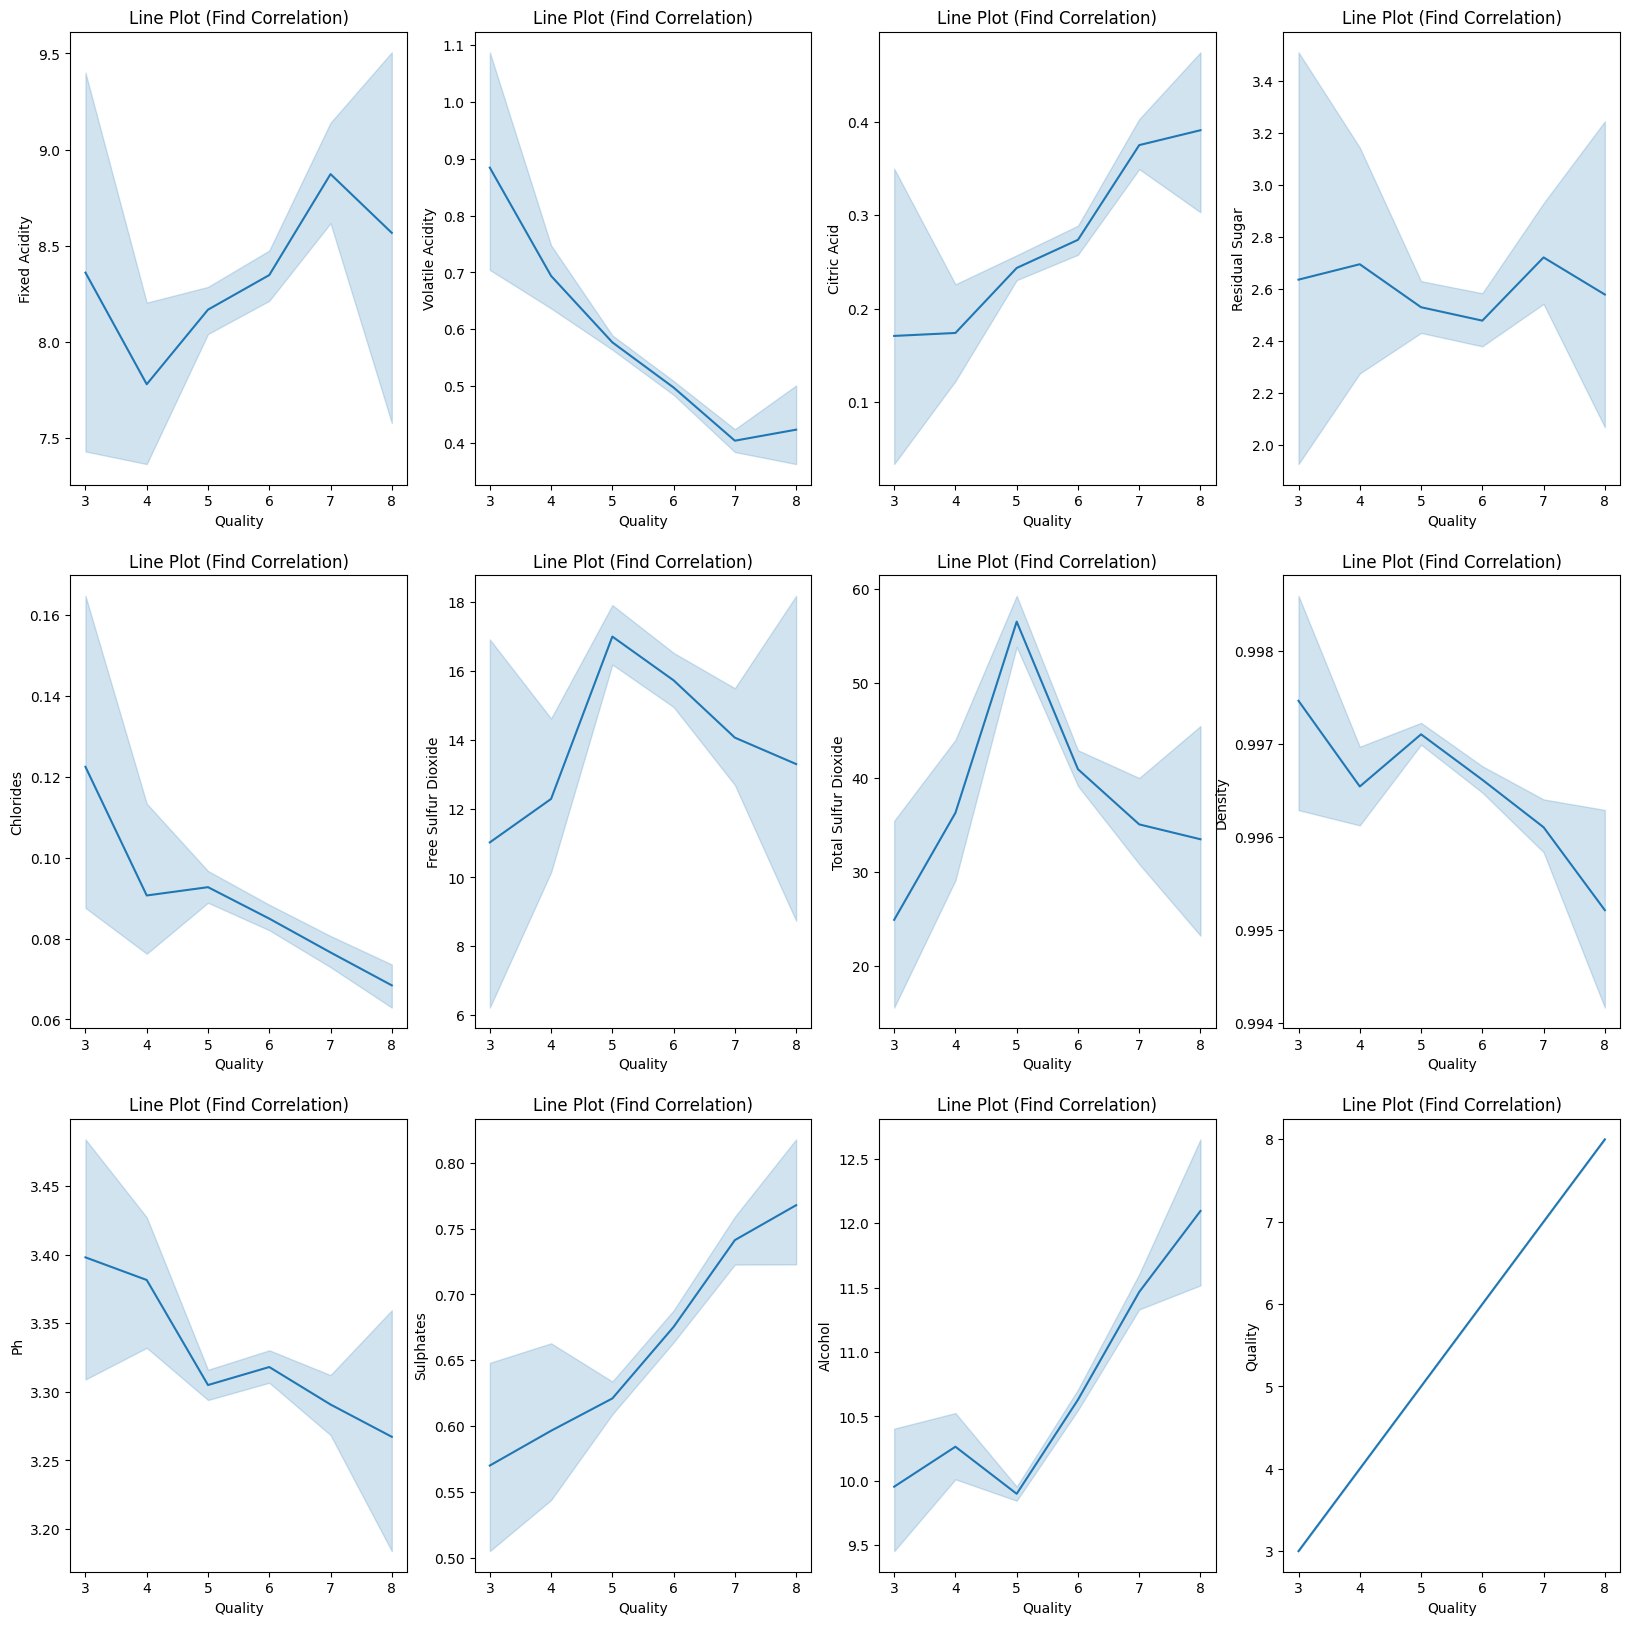

In [12]:
# Correlation Analysis
j = 1
plt.figure(figsize=(20,20))
for i in data_clean.columns:
    if j == 13:
        break
    plt.subplot(3,4,j)
    sns.lineplot(x = data_clean['quality'],y = data_clean[i])
    plt.title('Line Plot (Find Correlation)')
    plt.xlabel('Quality')
    plt.ylabel(f'{i.replace('_',' ').title()}')
    j += 1

### What the plots show
- **X-axis:** Wine quality score.  
- **Y-axis:** Different wine properties.  
- **Blue line:** Average trend.  
- **Shaded area:** Variation in data.  

### Key relationships
1. **Fixed Acidity & Citric Acid:** No big effect on quality.  
2. **Volatile Acidity:** More of this → lower quality.  
3. **Residual Sugar & Chlorides:** Weak link, not very important.  
4. **Sulfur Dioxide (Free & Total):** Too much → slightly lower quality.  
5. **Density & pH:** Little to no effect.  
6. **Sulphates:** More sulphates → better quality.  
7. **Alcohol:** Higher alcohol → better quality.  
8. **Quality vs Quality:** Straight line (same variable).  

### Takeaway
- **Strong factors:** Alcohol (good), Volatile Acidity (bad), Sulphates (good).  
- **Weak factors:** Acidity, Sugar, Density, pH.  
- **Moderate factor:** Sulfur compounds (too much is bad).  


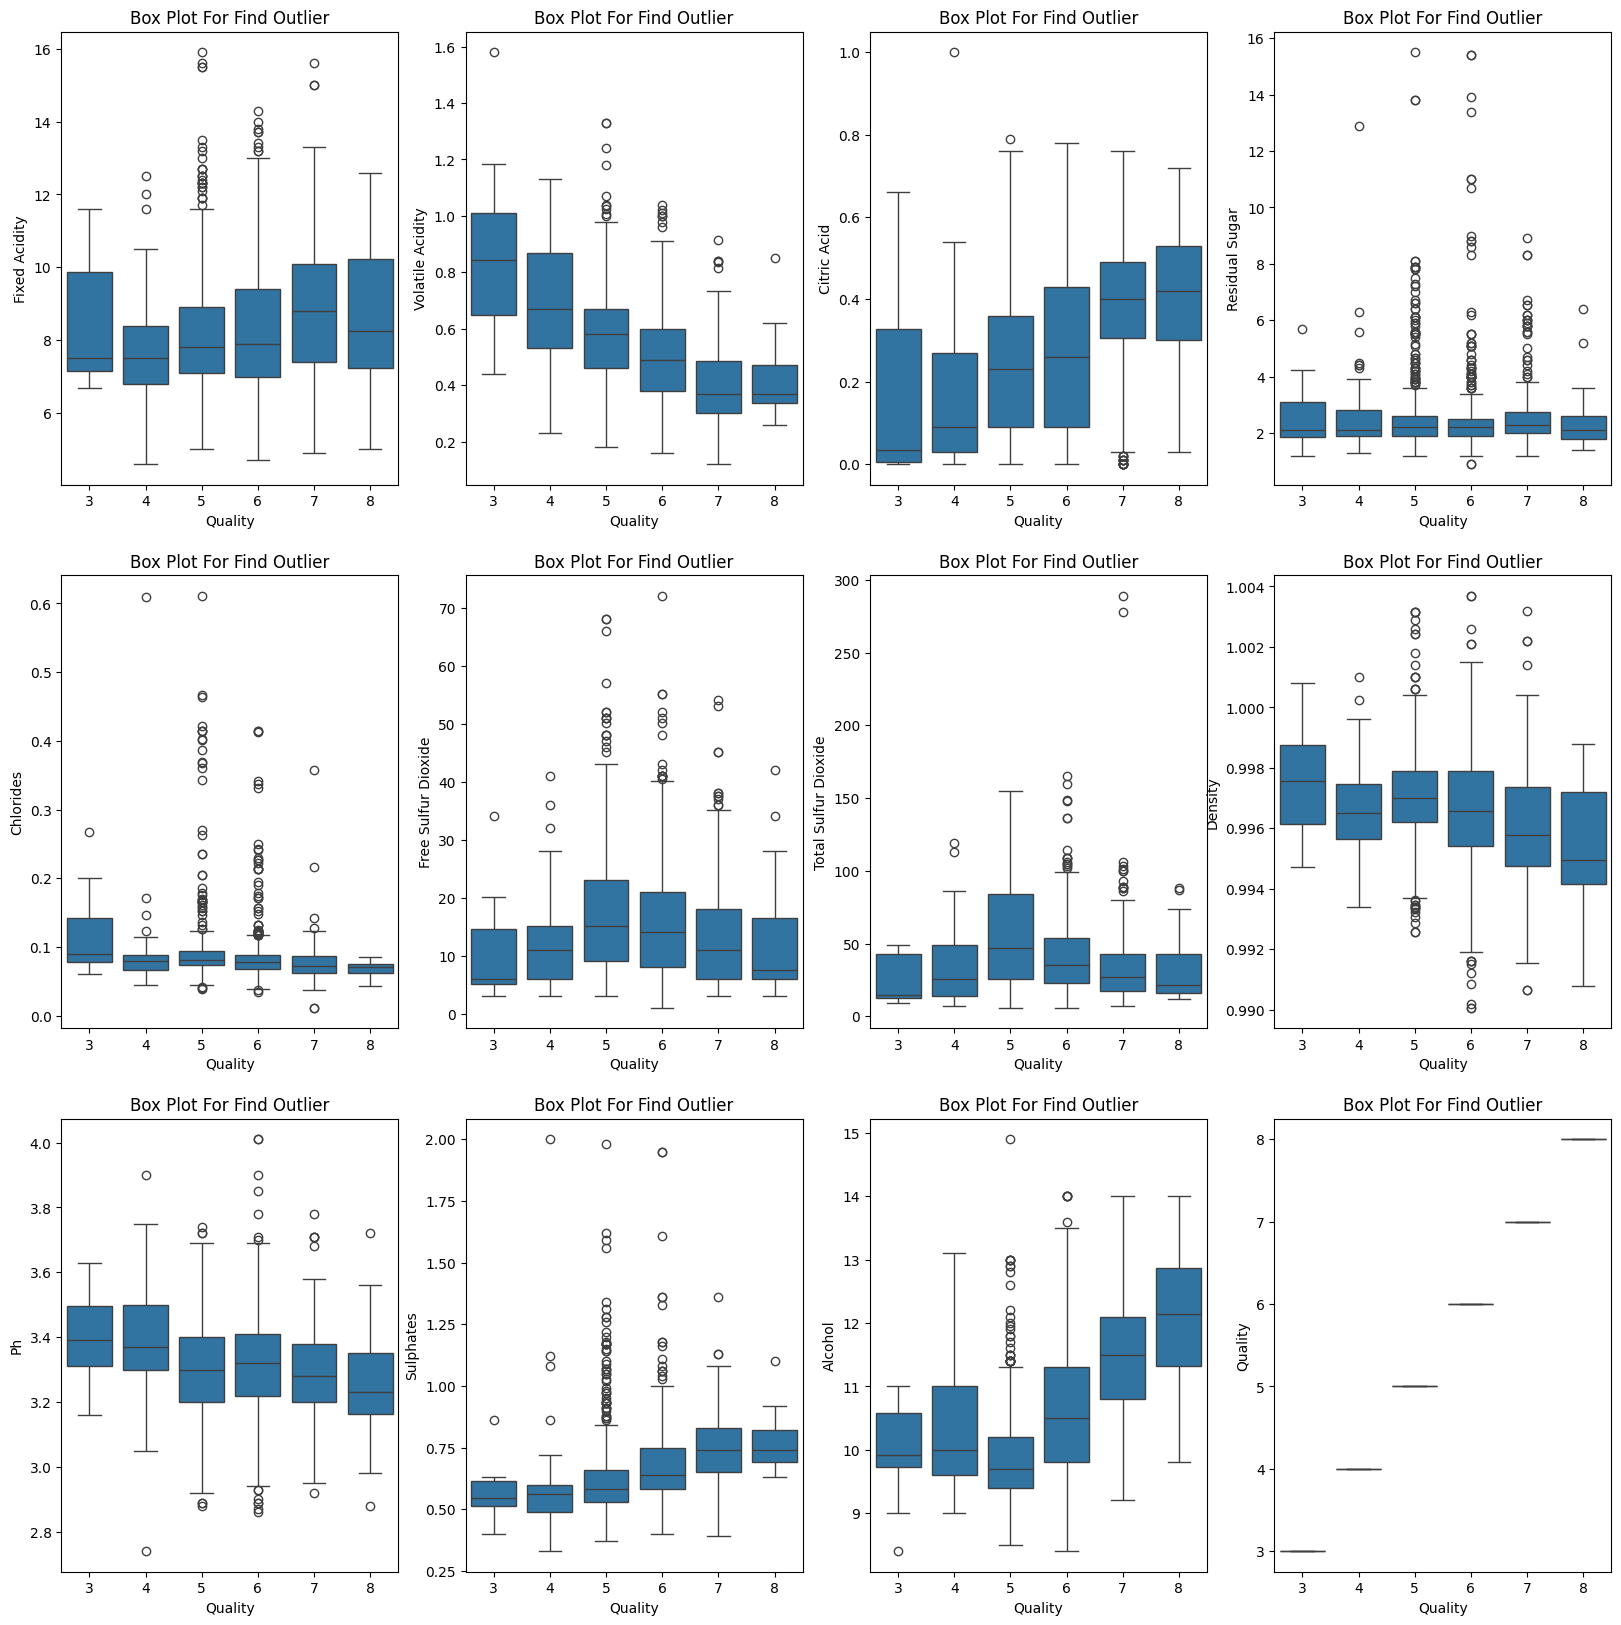

In [13]:
# Correlation Analysis
j = 1
plt.figure(figsize=(20,20))
for i in data_clean.columns:
    if j == 13:
        break
    plt.subplot(3,4,j)
    sns.boxplot(x = data_clean['quality'],y = data_clean[i])
    plt.title('Box Plot For Find Outlier')
    plt.xlabel('Quality')
    plt.ylabel(f'{i.replace('_',' ').title()}')
    j += 1

### What the plots show
- **X-axis (Quality):** Wine quality rating.  
- **Y-axis (Variable):** Each wine property.  
- **Boxes & whiskers:** Show the spread of values (median, quartiles).  
- **Dots outside whiskers:** Outliers — unusual values compared to the rest.  

### Key relationships
1. **Fixed Acidity & Citric Acid:** Spread is wide, but no clear pattern with quality.  
2. **Volatile Acidity:** Lower values are linked to higher quality; outliers appear at high acidity.  
3. **Residual Sugar & Chlorides:** Many outliers, but weak link to quality.  
4. **Sulfur Dioxide (Free & Total):** Large spread with many outliers; higher values don’t align with better quality.  
5. **Density & pH:** Mostly stable across quality, with scattered outliers.  
6. **Sulphates:** Higher sulphates tend to show up in better quality wines, though some outliers exist.  
7. **Alcohol:** Clear upward trend — higher alcohol levels are common in higher quality wines.  
8. **Quality vs Quality:** Just mirrors the rating itself.  


In [14]:
# # Outlier Treatment
# for i in data_clean.columns:
#     Q1 = data_clean[i].quantile(0.25)
#     Q3 = data_clean[i].quantile(0.75)
#     IQR = Q3 - Q1
#     LB = Q1 - 1.5 * IQR
#     UB = Q3 + 1.5 * IQR
#     data_clean = data_clean[ ~((data_clean[i] < LB) | (data_clean[i] > UB)) ]


**What this cell does:** nothing — it's fully commented out. It shows the IQR (interquartile range) method for outlier removal, which was apparently tried and then intentionally disabled (perhaps because it removed too much data, or because outlier removal wasn't shown to improve the model). Kept here as a documented "we considered this" note rather than deleted.


In [15]:
# # Correlation Analysis
# j = 1
# plt.figure(figsize=(20,20))
# for i in data_clean.columns:
#     if j == 13:
#         break
#     plt.subplot(3,4,j)
#     sns.boxplot(x = data_clean['quality'],y = data_clean[i])
#     plt.title('Box Plot For Find Outlier')
#     plt.xlabel('Quality')
#     plt.ylabel(f'{i.replace('_',' ').title()}')
#     j += 1

**What this cell does:** nothing — another commented-out duplicate of the earlier box-plot cell, presumably kept to re-run box plots *after* the (currently disabled) outlier treatment above, for a before/after comparison, if that step is ever re-enabled.


<Figure size 2000x2000 with 0 Axes>

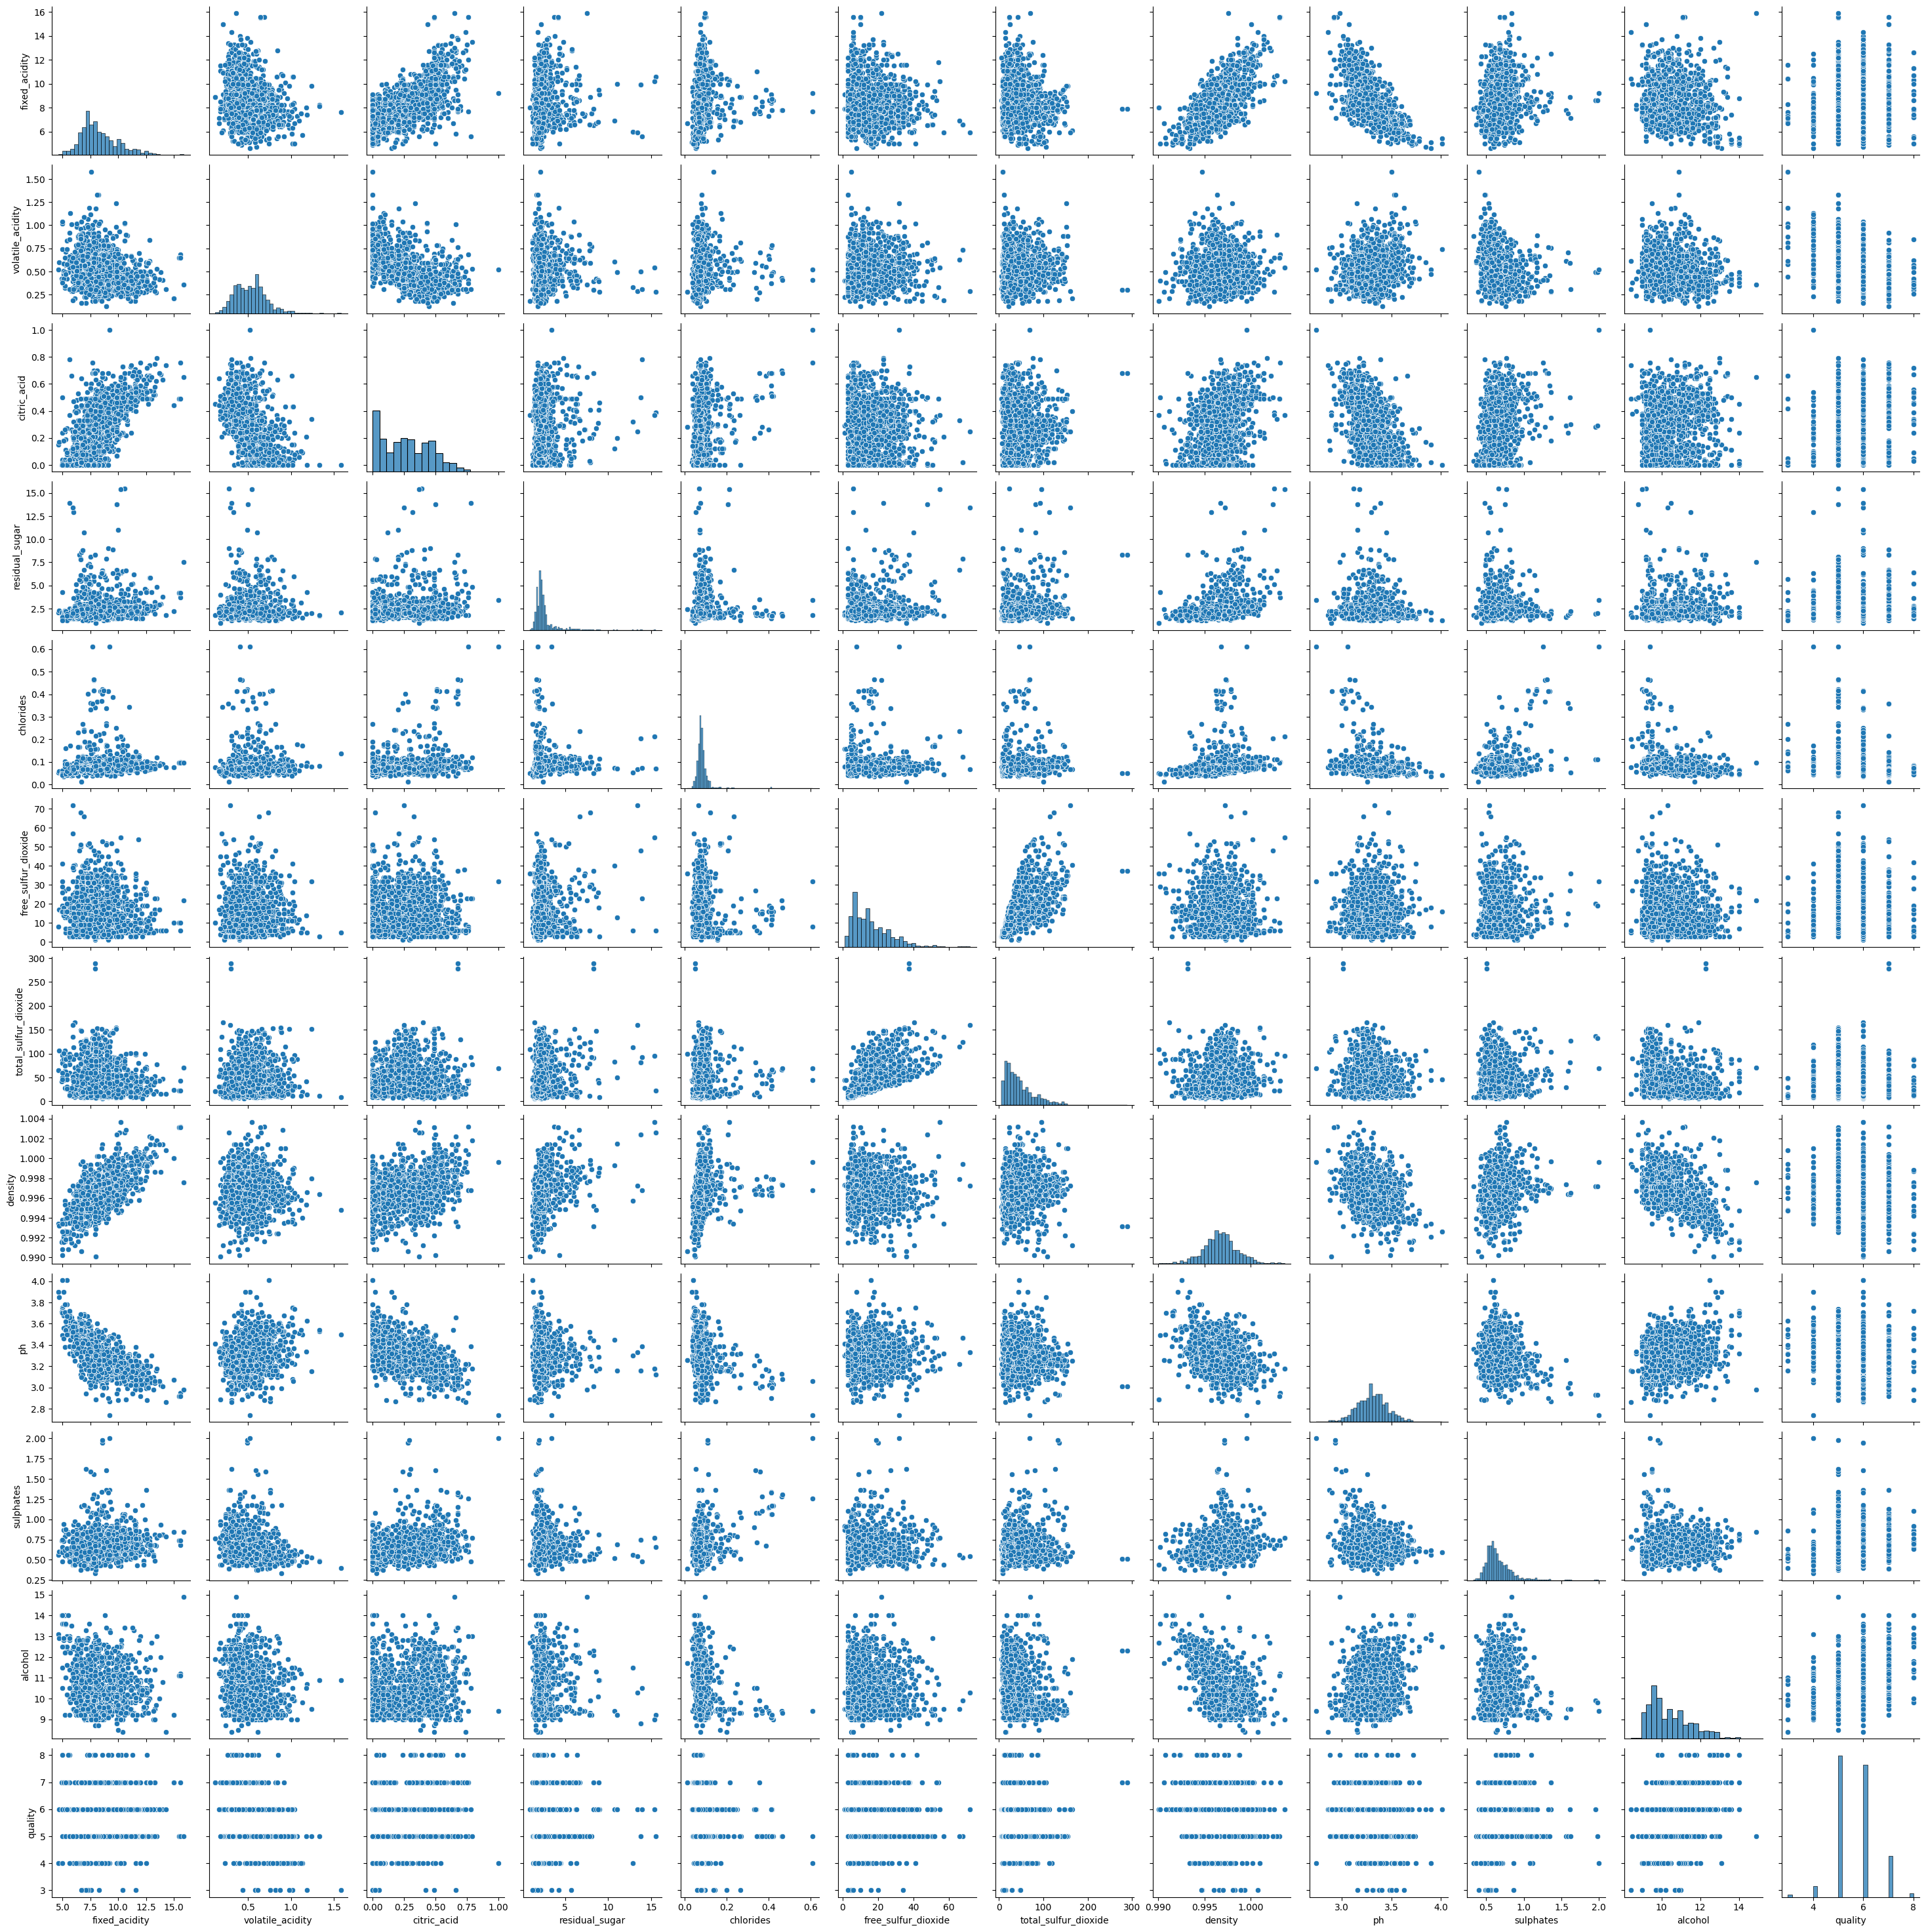

In [16]:
plt.figure(figsize=(20,20))
sns.pairplot(data = data_clean)
plt.savefig('Plot.png')

In [18]:
data_clean.to_csv("clean_dataset.csv")

**What this cell does:** produces a full pairplot (scatterplot matrix) of every column against every other column, and saves it to `Plot.png` in the working directory. This is the most expensive plotting cell in the notebook (11×11+ grid of scatterplots) and can take a while to render on the full dataset.
